Linear Regression - Slope: 2.770113386438484
Linear Regression - Intercept: 4.215096157546746


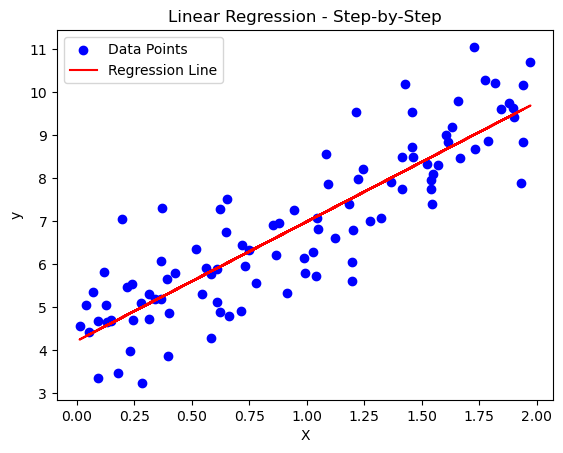

Logistic Regression - Intercept: 0.001407775910320545
Logistic Regression - Slope: 5.55034543231194


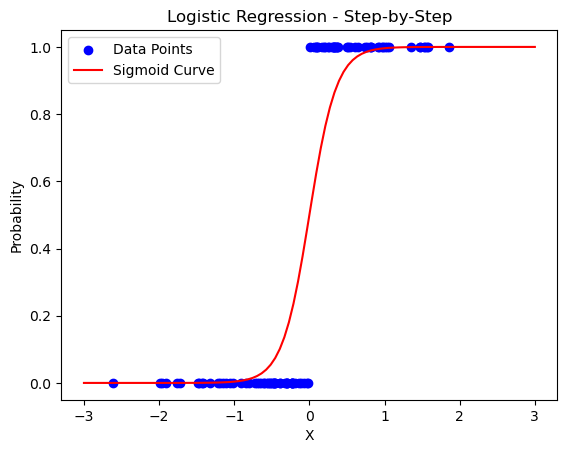

In [1]:
import numpy as np  # Importing NumPy for numerical computations
import matplotlib.pyplot as plt  # Importing Matplotlib for plotting
from sklearn.linear_model import LinearRegression, LogisticRegression  # Importing built-in models from sklearn
from sklearn.model_selection import train_test_split  # Function to split data into training and testing sets
from sklearn.metrics import mean_squared_error, accuracy_score  # Evaluation metrics for models

# ---------------------------- Linear Regression (Step-by-step) ----------------------------

def linear_regression_simple(X, y):
    """Computes Linear Regression parameters manually."""
    
    x_mean = np.mean(X)  # Compute mean of X
    y_mean = np.mean(y)  # Compute mean of y
    
    numerator = np.sum((X - x_mean) * (y - y_mean))  # Compute numerator of slope
    denominator = np.sum((X - x_mean) ** 2)  # Compute denominator of slope
    slope = numerator / denominator  # Compute slope (m)
    intercept = y_mean - slope * x_mean  # Compute intercept (b)
    
    return slope, intercept  # Return computed slope and intercept

# Generate synthetic dataset for Linear Regression
np.random.seed(42)
X = 2 * np.random.rand(100, 1)  # Random X values
y = 4 + 3 * X + np.random.randn(100, 1)  # Generate y with noise

slope, intercept = linear_regression_simple(X.flatten(), y.flatten())
print("Linear Regression - Slope:", slope)
print("Linear Regression - Intercept:", intercept)

# Plot the Linear Regression results
plt.scatter(X, y, color='blue', label='Data Points')  # Plot original data
plt.plot(X, intercept + slope * X, color='red', label='Regression Line')  # Plot regression line
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression - Step-by-Step")
plt.legend()
plt.show()

# ---------------------------- Logistic Regression (Step-by-step) ----------------------------

def sigmoid(z):
    """Computes the sigmoid function."""
    return 1 / (1 + np.exp(-z))

def logistic_regression_simple(X, y, learning_rate=0.1, epochs=1000):
    """Computes Logistic Regression parameters manually using gradient descent."""
    
    m, n = X.shape  # Number of samples and features
    X = np.c_[np.ones(m), X]  # Add intercept column (bias)
    theta = np.zeros(n + 1)  # Initialize weights
    
    for _ in range(epochs):  # Iterating through epochs
        predictions = sigmoid(X.dot(theta))  # Compute predictions using sigmoid function
        errors = predictions - y  # Compute errors
        gradients = (1/m) * X.T.dot(errors)  # Compute gradients
        theta -= learning_rate * gradients  # Update weights using gradient descent
    
    return theta  # Return trained weights

# Generate synthetic dataset for Logistic Regression
np.random.seed(42)
X = np.random.randn(100, 1)  # Randomly generate feature values
y = (X[:, 0] > 0).astype(int)  # Binary labels (1 if x > 0, else 0)

theta_logistic = logistic_regression_simple(X, y)
print("Logistic Regression - Intercept:", theta_logistic[0])
print("Logistic Regression - Slope:", theta_logistic[1])

# Plot the Logistic Regression results
x_values = np.linspace(-3, 3, 100)  # Generate values for plotting
z = theta_logistic[0] + theta_logistic[1] * x_values  # Compute decision boundary
probabilities = sigmoid(z)  # Compute sigmoid probabilities

plt.scatter(X, y, color='blue', label='Data Points')  # Plot original data
plt.plot(x_values, probabilities, color='red', label='Sigmoid Curve')  # Plot sigmoid function
plt.xlabel("X")
plt.ylabel("Probability")
plt.title("Logistic Regression - Step-by-Step")
plt.legend()
plt.show()
